In [36]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score
from sklearn.cluster import KMeans
%matplotlib inline


In [37]:
df = pd.read_csv('wisc_bc_ContinuousVar.csv')

# Fetching the first few rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [62]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [63]:
# Check for null values
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [64]:
# Dropping any null values if present
df = df.dropna()

In [65]:
# Distribution of diagnosis
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


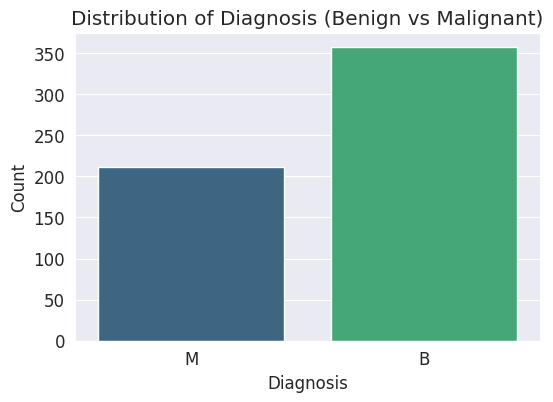

In [39]:
# Plot distribution of diagnosis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='viridis')
plt.title("Distribution of Diagnosis (Benign vs Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

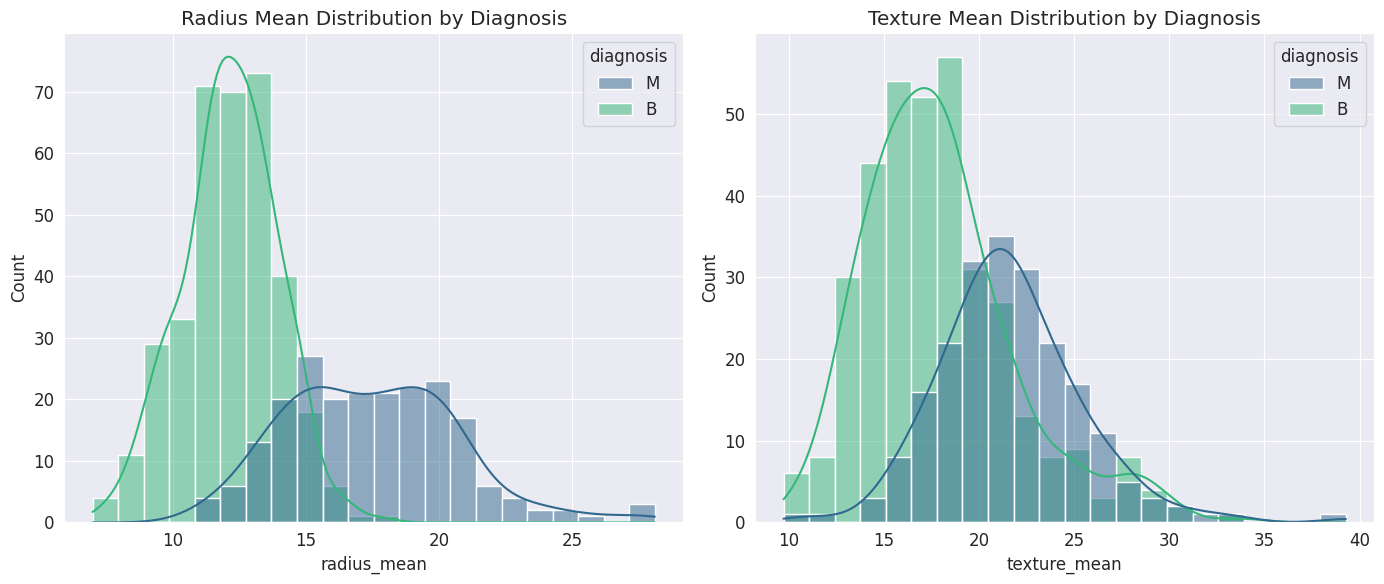

In [41]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, palette='viridis')
plt.title("Radius Mean Distribution by Diagnosis")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='texture_mean', hue='diagnosis', kde=True, palette='viridis')
plt.title("Texture Mean Distribution by Diagnosis")

plt.tight_layout()
plt.show()

In [42]:
# Separate the features and diagnosis column
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']


In [66]:
# Performing Standard scaling for hierarchical clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

In [44]:
# Calling hierarchical clustering with Ward's method
linkage_matrix = linkage(scaled_features, method='ward')

# Making two clusters
cluster_labels = fcluster(linkage_matrix, 2, criterion='maxclust')

# Creating a DataFrame for the cluster labels and diagnosis
clustered_data = pd.DataFrame({'Cluster': cluster_labels, 'Diagnosis': df['diagnosis']})

# Tabulate the clustered rows against the "diagnosis" column
cluster_tab = pd.crosstab(clustered_data['Cluster'], clustered_data['Diagnosis'])
print(cluster_tab)

Diagnosis    B    M
Cluster            
1          337   48
2           20  164


In [45]:
diagnosis_binary = np.where(df['diagnosis'] == 'M', 1, 0)

In [46]:
cluster_binary_labels = np.where(cluster_labels == 1, 0, 1)

In [47]:
accuracy = accuracy_score(diagnosis_binary, cluster_binary_labels)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8805


In [48]:
f1 = f1_score(diagnosis_binary, cluster_binary_labels)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8283


In [49]:
precision = precision_score(diagnosis_binary, cluster_binary_labels)
print(f"Precision: {precision:.4f}")

Precision: 0.8913


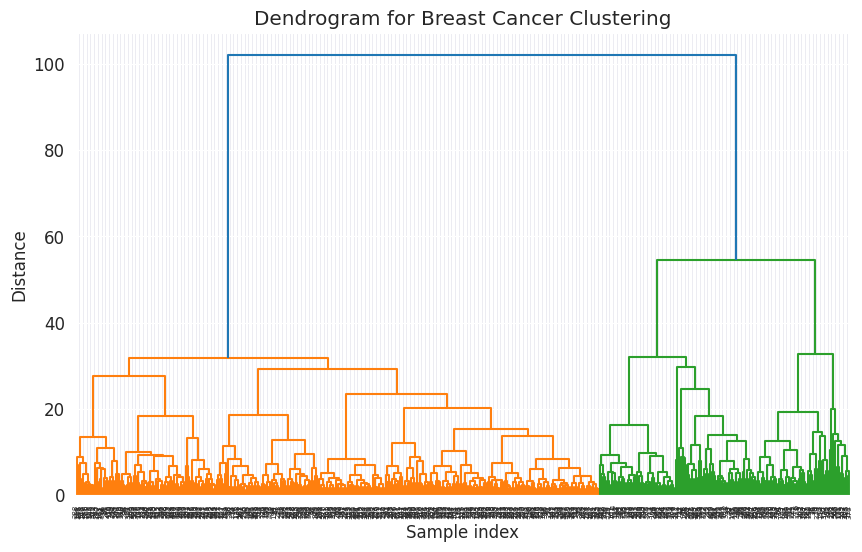

In [50]:
plt.figure(figsize=(10, 6))
plt.title("Hierarchical Clustering Dendrogram")
dendrogram_plot = dendrogram(linkage_matrix)
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.axhline(y=150, color='r', linestyle='--')  # To indicate the cut-off for 2 clusters
plt.title("Dendrogram for Breast Cancer Clustering")
plt.show()

In [51]:
# Performing K-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_features)

In [52]:
kmeans_clustered = pd.DataFrame({'Cluster': kmeans_labels, 'Diagnosis': df['diagnosis']})

In [53]:
kmeans_cluster_table = pd.crosstab(kmeans_clustered['Cluster'], kmeans_clustered['Diagnosis'])
print(kmeans_cluster_table)

Diagnosis    B    M
Cluster            
0           13  175
1          344   37


In [54]:
kmeans_binary_labels = kmeans_labels

In [55]:
# Calculate accuracy
kmeans_acc = accuracy_score(diagnosis_binary, kmeans_binary_labels)
print(f"Accuracy: {kmeans_acc:.4f}")

Accuracy: 0.0879


In [56]:
kmeans_f1 = f1_score(diagnosis_binary, kmeans_binary_labels)
print(f"F1 Score: {kmeans_f1:.4f}")

F1 Score: 0.1248


In [57]:
# Calculate Precision
kmeans_precision = precision_score(diagnosis_binary, kmeans_binary_labels)
print(f"Precision: {kmeans_precision:.4f}")

Precision: 0.0971


In [58]:
from sklearn.decomposition import PCA

In [59]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)


In [60]:
# Create a DataFrame for plotting
plot_df = pd.DataFrame(data=reduced_features, columns=['PC1', 'PC2'])
plot_df['diagnosis'] = df['diagnosis']
plot_df['cluster'] = kmeans_labels

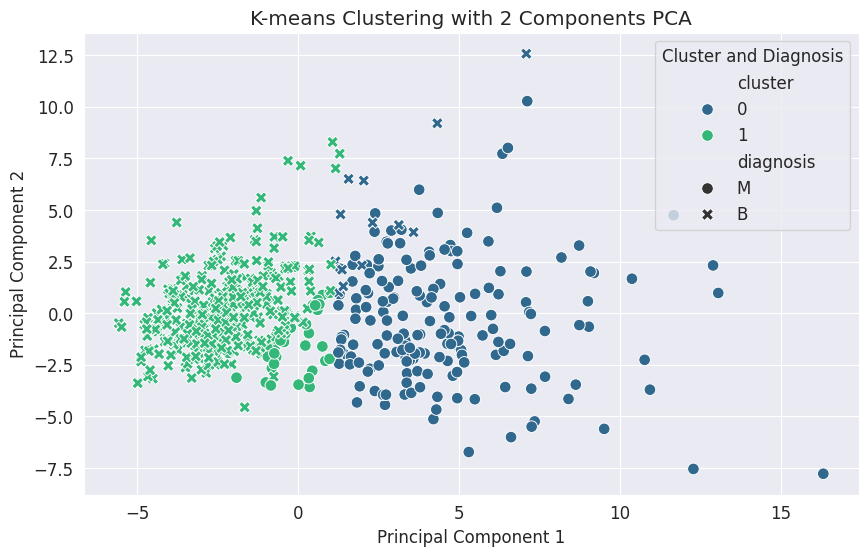

In [61]:
# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', style='diagnosis', palette='viridis', s=70)
plt.title('K-means Clustering with 2 Components PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster and Diagnosis')
plt.show()